# Causal Uplift Modeling on Criteo Uplift v2.1 — Data Understanding

This notebook establishes the decision problem, the causal design, and the data foundation this project builds on: what the data contains, whether it is trustworthy and complete, how the two experimental groups compare, and whether working with all of it is computationally practical. It closes with the train/validation/held-out design and the preprocessing decisions that follow from what is found here.

**What is not here.** No model is trained and nothing is predicted. This is the groundwork a reader needs before the modeling notebook that follows makes sense.

## 1. The decision problem

An advertiser can choose, for each person, whether to show them an ad. Showing an ad costs money and attention; not showing one risks a lost sale. The question worth answering is not *who is likely to buy* but **whose purchase is caused by seeing the ad** — because those are frequently different people.

That distinction is the entire subject of this project: given a person's pre-treatment characteristics, rank or select them by how much showing the ad **changes** their chance of converting, using [CRITEO-UPLIFTv2.1](https://ailab.criteo.com/criteo-uplift-prediction-dataset/), a large-scale randomized-assignment advertising dataset released for exactly this kind of research.

## 2. Why predicting who converts is not enough

The familiar tool for targeting is a response model: estimate $P(Y=1 \mid X)$, the probability of conversion given a person's features, and target whoever scores highest.

That model answers a different question than the one that matters here. Consider two people with very different response probabilities:

In [1]:
# Illustrative only — these four customers are invented and are NOT from the Criteo data.
import pandas as pd
from IPython.display import Markdown, display

illustration = pd.DataFrame({
    'customer': ['A', 'B', 'C', 'D'],
    'p_convert_if_treated': [0.90, 0.20, 0.55, 0.05],
    'p_convert_if_not_treated': [0.89, 0.10, 0.50, 0.01],
})
illustration['uplift'] = illustration['p_convert_if_treated'] - illustration['p_convert_if_not_treated']
illustration['rank_by_response'] = illustration['p_convert_if_treated'].rank(ascending=False).astype(int)
illustration['rank_by_uplift'] = illustration['uplift'].rank(ascending=False).astype(int)
display(illustration)

display(Markdown('''
**What this shows.** The two rankings disagree almost completely. Customer A is the best target by
conversion probability and the *worst* target by uplift; customer B is the reverse. She was going to
buy anyway — her uplift is about +1 point. He converts only if shown the ad — his uplift is +10 points.
Spend the budget on A and most of it buys conversions that would have happened regardless.

**What this does not show.** Nothing yet about the Criteo data — these are invented numbers used only
to make the distinction concrete.

**Why it matters next.** The only reason this question can be asked at all is that treatment here was
**randomly assigned**. Without randomization, treated and untreated people would differ systematically,
and the gap between their conversion rates would reflect who they are rather than what the ad did.
Everything below asks whether this dataset actually supports that comparison, and at what scale.
'''))

,customer,p_convert_if_treated,p_convert_if_not_treated,uplift,rank_by_response,rank_by_uplift
0,A,0.90,0.89,0.01,1,4
1,B,0.20,0.10,0.10,3,1
2,C,0.55,0.50,0.05,2,2
3,D,0.05,0.01,0.04,4,3



**What this shows.** The two rankings disagree almost completely. Customer A is the best target by
conversion probability and the *worst* target by uplift; customer B is the reverse. She was going to
buy anyway — her uplift is about +1 point. He converts only if shown the ad — his uplift is +10 points.
Spend the budget on A and most of it buys conversions that would have happened regardless.

**What this does not show.** Nothing yet about the Criteo data — these are invented numbers used only
to make the distinction concrete.

**Why it matters next.** The only reason this question can be asked at all is that treatment here was
**randomly assigned**. Without randomization, treated and untreated people would differ systematically,
and the gap between their conversion rates would reflect who they are rather than what the ad did.
Everything below asks whether this dataset actually supports that comparison, and at what scale.


## 3. Dataset and variable roles

CRITEO-UPLIFTv2.1 contains roughly 14 million released rows from a randomized advertising experiment. Each row is **one released observation** — not an assumed unique person. The public schema has no user identifier, so two identical rows might be two different people, or the same person twice; the data cannot tell us, and neither can we.

| Field | Role |
|---|---|
| `f0`–`f11` | the only model inputs. **Anonymous** — Criteo does not publish what they represent, and no meaning is invented for them here. |
| `treatment` | randomly assigned; 1 = ad shown, 0 = not shown |
| `conversion` | the primary outcome |
| `visit` | a secondary outcome, analysed separately; never an input |
| `exposure` | whether the ad was actually seen — diagnostic only, never an input |
| `_source_row_id` | a row ordinal used later for provenance and alignment; never a model input |

**Why `exposure` is never an input and never a filter.** Whether someone actually saw the ad happens *after* assignment and depends on their own behavior. Using it as a feature, or restricting the analysis to exposed rows, would swap a randomized comparison for a self-selected one. Throughout this project the effect of interest is the effect of *being assigned* the ad — not the effect of actually seeing it.

## 4. Causal question, estimand, and assumptions

**Uplift, in one line.** Uplift modeling (equivalently, CATE — conditional average treatment effect — modeling) targets

$$\tau(x) = E[Y(1) - Y(0) \mid X = x],$$

the expected change in outcome caused by treatment, for people who share features $x$. It is a **contrast**, not a level.

**Why it is estimated, not observed.** For a row $i$, $Y_i(1)$ is the outcome that would occur if it were treated and $Y_i(0)$ the outcome if not. The individual effect $Y_i(1)-Y_i(0)$ is well defined but never observed: a row is either treated or not, so only one of the two is ever realized. This is the fundamental problem of causal inference. A fitted model's output, $\hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$, is an **estimate of a conditional average contrast** — called predicted uplift or estimated CATE throughout this project, never a true individual treatment effect, and never validated against one, since no such ground truth exists on this dataset.

**The target estimand** is the assignment (intention-to-treat) CATE, $\tau(x)$, over the eligible released population; the population average $ATE=E[Y(1)-Y(0)]$ is a secondary summary. Using assignment rather than realized exposure keeps the randomized comparison intact: assignment was decided before any of a person's own downstream behavior, while exposure was not.

**What this relies on, and cannot prove from the data alone.**

- **Exchangeability** — assignment independent of potential outcomes. Supported by the randomized design; not something a balance check can prove, only be consistent with.
- **Positivity/overlap** — both arms represented in the relevant feature regions. Checked empirically below.
- **Pre-treatment covariates** — every field in `X` must precede assignment. Timing is not independently source-verified for this anonymized release.
- **No interference** — one row's assignment must not affect another's outcome. Plausible for individually targeted ads, not verifiable without a network or household identifier, which this schema lacks.
- **Consistent, well-defined outcomes** — `conversion` must mean the same thing for every row over a comparable window.

Conclusions are scoped to the released population under its observed assignment and covariate support — not other users, campaigns, platforms, or time periods.

## 5. Data quality and structural checks

Before anything else, four questions have to be answered about the file itself: does it hold what the schema promises, is anything missing or malformed, how many rows are indistinguishable from one another, and does the numeric precision used for the features invent collisions that are not really in the data?

Repeated analytical queries against a compressed, row-oriented CSV are expensive — every query re-decompresses and re-parses the file from the beginning. This notebook therefore converts the file once to a typed columnar copy and runs every diagnostic below against that copy; [section 9](#9.-Full-data-computational-feasibility) measures directly whether that conversion was worth its cost.

In [2]:
# Setup: locate the input, open the query engine, and convert once to a columnar copy.
# Runs on Kaggle (with the Criteo uplift dataset attached) and locally, with no other dependencies.
import math
import tempfile
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

FEATURES = [f'f{i}' for i in range(12)]
TREATMENT, OUTCOME, SECONDARY, DIAGNOSTIC = 'treatment', 'conversion', 'visit', 'exposure'


def find_input():
    '''Kaggle input first, then common local locations.'''
    for root in [Path('/kaggle/input'), Path('data/raw'), Path('../data/raw'), Path('.')]:
        if not root.is_dir():
            continue
        for pattern in ('**/*.csv.gz', '**/*.csv'):
            for candidate in sorted(root.glob(pattern)):
                if 'criteo' in candidate.name.lower():
                    return candidate
    raise FileNotFoundError(
        'Could not find the Criteo uplift file. On Kaggle, attach the Criteo uplift dataset; '
        'locally, place it under data/raw/.'
    )


def sql_literal(value):
    '''Quote a path for use inside a SQL string literal.'''
    quote = chr(39)
    return quote + str(value).replace(quote, quote * 2) + quote


INPUT_PATH = find_input()
# Scratch space for the derived columnar copy. On Kaggle this is /kaggle/working; locally it is the
# OS temp directory, deliberately NOT anywhere inside the repository. The copy is throwaway: a
# working artifact for this notebook, not a curated or published dataset.
WORK_DIR = Path('/kaggle/working') if Path('/kaggle/working').is_dir() else Path(tempfile.gettempdir())
PARQUET_PATH = WORK_DIR / 'criteo-uplift-v2.1-data-understanding.parquet'

# No thread or memory cap: the engine is left to configure itself. Imposing an artificial cap would
# answer the wrong question — whether the work fits under that cap — rather than whether it is
# feasible on this platform. Whatever the engine chooses is reported in section 9.
con = duckdb.connect(database=':memory:')
con.execute(f'CREATE VIEW raw AS SELECT * FROM read_csv_auto({sql_literal(INPUT_PATH)})')

if PARQUET_PATH.exists():
    existing_rows = con.execute(f'SELECT COUNT(*) FROM read_parquet({sql_literal(PARQUET_PATH)})').fetchone()[0]
    raw_rows = con.execute('SELECT COUNT(*) FROM raw').fetchone()[0]
    reused = existing_rows == raw_rows
    if not reused:
        PARQUET_PATH.unlink()
else:
    reused = False

if not reused:
    con.execute(
        f'COPY (SELECT * FROM raw) TO {sql_literal(PARQUET_PATH)} '
        '(FORMAT PARQUET, COMPRESSION ZSTD)'
    )
con.execute(f'CREATE OR REPLACE VIEW data AS SELECT * FROM read_parquet({sql_literal(PARQUET_PATH)})')

print(f'Input file: {INPUT_PATH}')
print(f'Columnar copy: {PARQUET_PATH} (reused from an earlier run: {reused})')

Input file: ..\data\raw\criteo-uplift-v2.1.csv.gz
Columnar copy: C:\Users\phunm5\AppData\Local\Temp\criteo-uplift-v2.1-data-understanding.parquet (reused from an earlier run: True)


In [3]:
# Schema, size, and completeness of every field the analysis depends on — one pass over the data.
schema = con.execute('DESCRIBE data').df()[['column_name', 'column_type']]
present = [c for c in FEATURES + [TREATMENT, OUTCOME, SECONDARY, DIAGNOSTIC]
           if c in schema['column_name'].tolist()]

missing_exprs = ', '.join(f'COUNT(*) - COUNT({c}) AS miss_{c}' for c in present)
sanity = con.execute(f'SELECT COUNT(*) AS n_rows, {missing_exprs} FROM data').df().iloc[0]
total_n = int(sanity['n_rows'])
missing_total = int(sum(int(sanity[f'miss_{c}']) for c in present))

roles = {c: 'model input' for c in FEATURES}
roles.update({TREATMENT: 'randomized assignment', OUTCOME: 'primary outcome',
              SECONDARY: 'secondary outcome (never an input)',
              DIAGNOSTIC: 'diagnostic only (never an input)'})
display(pd.DataFrame({
    'field': present,
    'stored type': [schema.loc[schema['column_name'] == c, 'column_type'].iloc[0] for c in present],
    'role': [roles[c] for c in present],
    'missing values': [int(sanity[f'miss_{c}']) for c in present],
}))

display(Markdown(f'''
**What this shows.** The file holds **{total_n:,} rows** and **{len(schema)} columns**, and every
field this analysis depends on is present. Total missing values across all of them: **{missing_total:,}**.

**What this does not show.** A complete, well-typed table says nothing about whether the experiment
was run correctly, or whether the features were measured before treatment — those are claims about
the study design, examined as far as data allows in section 8.

**Why it matters next.** Because nothing is missing, every count and rate below runs on the full
released population with nothing silently dropped.
'''))

,field,stored type,role,missing values
0,f0,DOUBLE,model input,0
1,f1,DOUBLE,model input,0
2,f2,DOUBLE,model input,0
3,f3,DOUBLE,model input,0
4,f4,DOUBLE,model input,0
5,f5,DOUBLE,model input,0
6,f6,DOUBLE,model input,0
7,f7,DOUBLE,model input,0
8,f8,DOUBLE,model input,0
9,f9,DOUBLE,model input,0



**What this shows.** The file holds **13,979,592 rows** and **16 columns**, and every
field this analysis depends on is present. Total missing values across all of them: **0**.

**What this does not show.** A complete, well-typed table says nothing about whether the experiment
was run correctly, or whether the features were measured before treatment — those are claims about
the study design, examined as far as data allows in section 8.

**Why it matters next.** Because nothing is missing, every count and rate below runs on the full
released population with nothing silently dropped.


**Repeated profiles.** Some rows carry exactly the same twelve feature values — a model cannot tell them apart. It is tempting to call these duplicate users and remove them; that would be a mistake for two reasons. First, there is no person identifier, so identical anonymous features are not evidence of the same person — with twelve coarse features spread over roughly 14 million rows, coincidental matches are expected even if every row is a different individual. Second, the released population *is* the population the conclusions are about; dropping repeated rows quietly redefines what is being estimated, invisibly. Every row is therefore kept, and repeated profiles are measured, never removed.

A related, separate question: does storing the features at **lower numeric precision** invent collisions that are not really in the data? Both are measured below, each grouping computed exactly once.

In [4]:
# Repeated-profile groupings under three definitions, plus a 64-bit vs 32-bit precision comparison.
def profile_groups(label, columns, relation='data'):
    grouped = ', '.join(columns)
    row = con.execute(f'''
        WITH groups AS (
            SELECT hash({grouped}) AS profile, COUNT(*) AS n
            FROM {relation} GROUP BY profile
        )
        SELECT COUNT(*) FILTER (WHERE n > 1),
               COALESCE(SUM(n) FILTER (WHERE n > 1), 0),
               MAX(n)
        FROM groups
    ''').fetchone()
    return {'grouped by': label, 'repeated groups': int(row[0]), 'rows in repeated groups': int(row[1]),
            'largest group': int(row[2]), 'share of all rows': int(row[1]) / total_n}

duplicates = pd.DataFrame([
    profile_groups('the 12 features only', FEATURES),
    profile_groups('features + treatment', FEATURES + [TREATMENT]),
    profile_groups('features + treatment + conversion', FEATURES + [TREATMENT, OUTCOME]),
])
display(duplicates)

reduced = '(SELECT ' + ', '.join(f'CAST({c} AS FLOAT) AS {c}' for c in FEATURES) + ' FROM data)'
precision = pd.DataFrame([
    profile_groups('64-bit precision (used throughout)', FEATURES),
    profile_groups('32-bit precision (comparison only)', FEATURES, relation=reduced),
])
display(precision[['grouped by', 'rows in repeated groups', 'largest group']])

feature_only = duplicates.iloc[0]
rows_64 = int(precision.iloc[0]['rows in repeated groups'])
rows_32 = int(precision.iloc[1]['rows in repeated groups'])
extra = rows_32 - rows_64

display(Markdown(f'''
**What this shows.** Grouping on the twelve features alone, **{feature_only['rows in repeated groups']:,}
rows** ({feature_only['share of all rows']:.2%} of the data) share their profile with at least one other
row. Adding treatment, then conversion, splits these into progressively smaller groups. Casting to
32-bit precision changes the count of repeated rows by **{extra:,}** ({extra / total_n:.4%} of the data)
— collisions that are an artifact of rounding, not a property of the underlying data.

**What this does not show.** None of these numbers count *people*; without a user identifier there is
no way to separate one person appearing repeatedly from many people who happen to look identical.
Grouping uses a 64-bit hash, so a negligible number of groups could be hash collisions rather than true
matches.

**Why it matters next.** Because rounding can merge genuinely distinct rows, the analysis keeps the
features at full 64-bit precision throughout; 32-bit is a sensitivity comparison only, never the primary
representation. Repeated profiles carrying different outcomes are informative rather than
contradictory — they are exactly the comparisons an uplift model learns from, which is why every row
is kept.
'''))

,grouped by,repeated groups,rows in repeated groups,largest group,share of all rows
0,the 12 features only,1185455,2811714,13,0.201130
1,features + treatment,970146,2240397,12,0.160262
2,features + treatment + conversion,969995,2240034,12,0.160236


,grouped by,rows in repeated groups,largest group
0,64-bit precision (used throughout),2811714,13
1,32-bit precision (comparison only),3560505,24



**What this shows.** Grouping on the twelve features alone, **2,811,714
rows** (20.11% of the data) share their profile with at least one other
row. Adding treatment, then conversion, splits these into progressively smaller groups. Casting to
32-bit precision changes the count of repeated rows by **748,791** (5.3563% of the data)
— collisions that are an artifact of rounding, not a property of the underlying data.

**What this does not show.** None of these numbers count *people*; without a user identifier there is
no way to separate one person appearing repeatedly from many people who happen to look identical.
Grouping uses a 64-bit hash, so a negligible number of groups could be hash collisions rather than true
matches.

**Why it matters next.** Because rounding can merge genuinely distinct rows, the analysis keeps the
features at full 64-bit precision throughout; 32-bit is a sensitivity comparison only, never the primary
representation. Repeated profiles carrying different outcomes are informative rather than
contradictory — they are exactly the comparisons an uplift model learns from, which is why every row
is kept.


## 6. Treatment and outcome overview

Two different things are easy to confuse: how lopsided the *treatment* split is, and how rare the *outcome* is. They have separate consequences — the smaller arm limits precision for anything estimated within it; outcome rarity limits precision everywhere — so they are measured together but reported separately, along with a check that all four combinations of assignment and outcome actually occur.

,treatment,conversion,n,arm_n,within_arm_rate
0,0,0,2092874,2096937,0.998062
1,0,1,4063,2096937,0.001938
2,1,0,11845944,11882655,0.996911
3,1,1,36711,11882655,0.003089


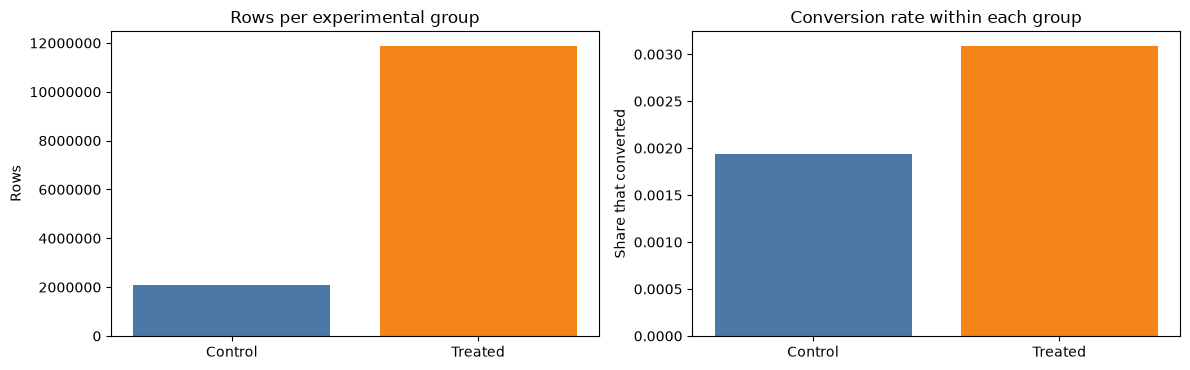


**What this shows.** The split is heavily lopsided: **85.0%** of rows were treated
(11,882,655 against 2,096,937 control). Conversion is rare — **0.2917%** overall,
**0.1938%** for control and **0.3089%** for treated, a raw gap of
**0.1152 percentage points**. All four combinations of treatment and
conversion are populated: **True**.

**What this does not show.** An uneven split is not a flaw — experiments are often designed this way —
and it says nothing about whether assignment was genuinely random; that is examined in section 8. The
raw rate gap is a comparison of two averages, not a per-person effect, and says nothing about *which*
people any effect is concentrated in.

**Why it matters next.** The smaller arm caps precision for anything estimated within it; a method that
fits a separate model per arm inherits that imbalance directly. And it is the count of *conversions*,
not the count of rows, that limits how finely the data can be sliced.


In [5]:
# Assignment and outcome, in one pass: group sizes, conversion rates by arm, and the full 2x2 table.
joint = con.execute(f'''
    SELECT {TREATMENT} AS treatment, {OUTCOME} AS conversion, COUNT(*) AS n
    FROM data GROUP BY 1, 2 ORDER BY 1, 2
''').df()
joint['arm_n'] = joint.groupby('treatment')['n'].transform('sum')
joint['within_arm_rate'] = joint['n'] / joint['arm_n']
display(joint)

treated_n = int(joint.loc[joint.treatment == 1, 'n'].sum())
control_n = int(joint.loc[joint.treatment == 0, 'n'].sum())
treated_share = treated_n / total_n
control_rate = float(joint[(joint.treatment == 0) & (joint.conversion == 1)]['within_arm_rate'].iloc[0])
treated_rate = float(joint[(joint.treatment == 1) & (joint.conversion == 1)]['within_arm_rate'].iloc[0])
overall_rate = float(joint[joint.conversion == 1]['n'].sum()) / total_n
all_four_present = bool(len(joint) == 4 and (joint['n'] > 0).all())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(['Control', 'Treated'], [control_n, treated_n], color=['#4C78A8', '#F58518'])
axes[0].set_ylabel('Rows')
axes[0].set_title('Rows per experimental group')
axes[0].ticklabel_format(axis='y', style='plain')
axes[1].bar(['Control', 'Treated'], [control_rate, treated_rate], color=['#4C78A8', '#F58518'])
axes[1].set_ylabel('Share that converted')
axes[1].set_title('Conversion rate within each group')
fig.tight_layout()
plt.show()

display(Markdown(f'''
**What this shows.** The split is heavily lopsided: **{treated_share:.1%}** of rows were treated
({treated_n:,} against {control_n:,} control). Conversion is rare — **{overall_rate:.4%}** overall,
**{control_rate:.4%}** for control and **{treated_rate:.4%}** for treated, a raw gap of
**{(treated_rate - control_rate) * 100:.4f} percentage points**. All four combinations of treatment and
conversion are populated: **{all_four_present}**.

**What this does not show.** An uneven split is not a flaw — experiments are often designed this way —
and it says nothing about whether assignment was genuinely random; that is examined in section 8. The
raw rate gap is a comparison of two averages, not a per-person effect, and says nothing about *which*
people any effect is concentrated in.

**Why it matters next.** The smaller arm caps precision for anything estimated within it; a method that
fits a separate model per arm inherits that imbalance directly. And it is the count of *conversions*,
not the count of rows, that limits how finely the data can be sliced.
'''))

## 7. Exploratory data analysis

Nothing can be said about what `f0`–`f11` *mean*, but their *shape* — range, where the mass sits, how many distinct values each takes — is directly informative for modeling. Cardinality matters most: a feature with a handful of distinct values behaves like a category; one with millions behaves like a continuous measurement, and tree-based models split the two very differently.

Cardinality and quantile figures below use DuckDB's approximate aggregates, which keeps a full pass over ~14 million rows fast; this is a genuine accuracy/speed trade-off — figures are accurate to within a small tolerance, not exact — and is why they are marked with a tilde. Minimum, maximum, and missing counts are exact.

In [6]:
# Per-feature shape: approximate cardinality and quantiles, exact range and missingness.
QUANTILES = [0.01, 0.25, 0.50, 0.75, 0.99]
exprs = []
for f in FEATURES:
    exprs += [
        f'approx_count_distinct({f}) AS {f}__nunique',
        f'MIN({f}) AS {f}__min',
        f'approx_quantile({f}, {QUANTILES}) AS {f}__q',
        f'MAX({f}) AS {f}__max',
    ]
cursor = con.execute('SELECT ' + ', '.join(exprs) + ' FROM data')
values = dict(zip([d[0] for d in cursor.description], cursor.fetchone()))

feature_summary = pd.DataFrame([{
    'feature': f,
    'distinct values ~': values[f + '__nunique'],
    'min': values[f + '__min'],
    'q25 ~': values[f + '__q'][1],
    'median ~': values[f + '__q'][2],
    'q75 ~': values[f + '__q'][3],
    'max': values[f + '__max'],
} for f in FEATURES])
display(feature_summary)

low_cardinality = feature_summary[feature_summary['distinct values ~'] <= 50]['feature'].tolist()
high_cardinality = feature_summary[feature_summary['distinct values ~'] > 100000]['feature'].tolist()

display(Markdown(f'''
**What this shows.** The twelve features are not interchangeable. Roughly category-like (50 or fewer
distinct values): **{low_cardinality or 'none'}**. Effectively continuous (over 100,000 distinct
values): **{high_cardinality or 'none'}**. No feature has missing values (section 5).

**What this does not show.** Nothing about meaning — a feature with four distinct values might be a
device type or a coarse bucket of something continuous; there is no way to tell, and guessing would be
fiction.

**Why it matters next.** These shapes decide how each feature is naturally handled downstream, and the
absence of missing values removes one decision — an imputation rule — that could otherwise be applied
differently to the treated and control arms.
'''))

,feature,distinct values ~,min,q25 ~,median ~,q75 ~,max
0,f0,1987595,12.616365,12.620180,21.909154,24.446192,26.745255
1,f1,58,10.059654,10.059654,10.059654,10.059654,16.344187
2,f2,2369986,8.214383,8.214383,8.214520,8.723399,9.051962
3,f3,524,-8.398387,4.679882,4.679882,4.679882,4.679882
4,f4,305,10.280525,10.280525,10.280525,10.280525,21.123508
5,f5,127,-9.011892,4.115453,4.115453,4.115453,4.115453
6,f6,1420,-31.429784,-6.692828,-2.412051,0.294029,0.294443
7,f7,757868,4.833815,4.833815,4.833815,4.833815,11.998401
8,f8,3898,3.635107,3.912082,3.971856,3.971858,3.971858
9,f9,1519,13.190056,13.190056,13.190056,13.190056,75.295017



**What this shows.** The twelve features are not interchangeable. Roughly category-like (50 or fewer
distinct values): **none**. Effectively continuous (over 100,000 distinct
values): **['f0', 'f2', 'f7', 'f10']**. No feature has missing values (section 5).

**What this does not show.** Nothing about meaning — a feature with four distinct values might be a
device type or a coarse bucket of something continuous; there is no way to tell, and guessing would be
fiction.

**Why it matters next.** These shapes decide how each feature is naturally handled downstream, and the
absence of missing values removes one decision — an imputation rule — that could otherwise be applied
differently to the treated and control arms.


## 8. Treatment–control comparability

Random assignment should make the two arms statistically alike on everything measured before treatment. Three complementary views, because each catches something the others miss:

- **Standardized mean difference (SMD)** — the gap between arm means in pooled standard deviations, making features on different scales comparable.
- **Variance ratio** — whether the arms have similar spread, not just similar centers.
- **KS distance** — the largest gap between the two arms' cumulative distributions, catching shape differences that means and variances both miss.

A dashed ±0.10 line appears on the SMD chart below — a rule of thumb from the observational-studies literature, drawn for orientation only. **Nothing here passes or fails because of it.** And the caveat that matters most: balance does **not** prove randomization. Arms that look alike are *consistent with* random assignment, a considerably weaker statement than proof. With roughly 14 million rows, conventional significance tests would flag differences far too small to matter, so none are used.

,feature,SMD,abs SMD,variance ratio,KS distance
0,f0,-0.006866,0.006866,0.995348,0.008950
1,f1,0.023994,0.023994,1.316448,0.002662
2,f2,-0.006241,0.006241,0.989375,0.003775
3,f3,-0.048836,0.048836,1.185681,0.013794
4,f4,0.007966,0.007966,1.032354,0.002412
5,f5,-0.030557,0.030557,1.220884,0.006099
6,f6,-0.040448,0.040448,1.072850,0.013069
7,f7,0.021270,0.021270,1.086321,0.006099
8,f8,-0.022433,0.022433,1.052023,0.008334
9,f9,0.024001,0.024001,1.076103,0.007125


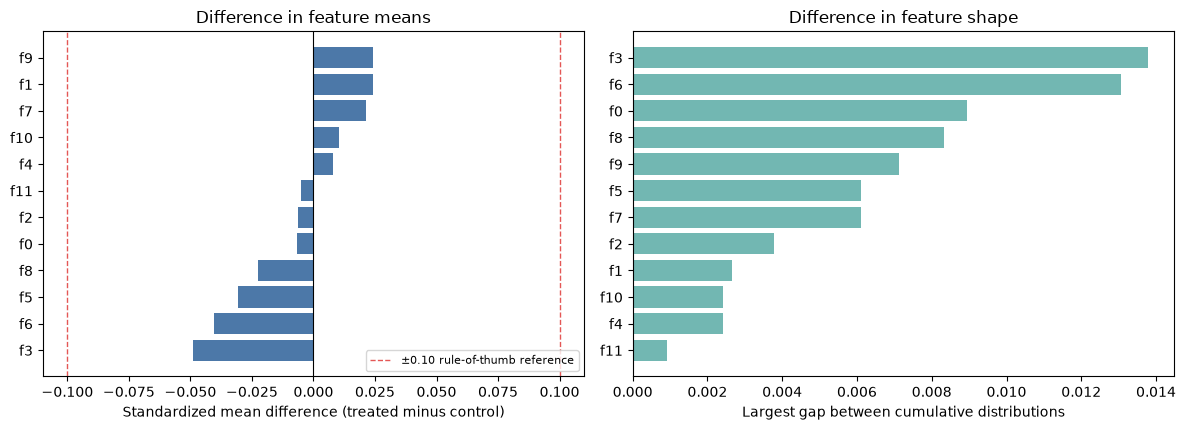


**What this shows.** The largest mean imbalance is an absolute SMD of **0.0488** on
`f3`; the largest distributional gap is a KS distance of
**0.0138** on `f3`. Variance ratios lie between
**0.989** and **1.316**.

**What this does not show.** This cannot prove assignment was random, cannot speak to anything
unmeasured, and cannot rule out differences confined to a region of feature space too small to move a
global average.

**Why it matters next.** Had these numbers been large, the raw conversion-rate gap from section 6 would
be uninterpretable. They are small, which is consistent with random assignment — and is what makes
uplift modeling a sensible thing to attempt on this data.


In [7]:
# Balance: mean, variance, and KS distance for every feature, both arms, computed in one pass plus
# one per-feature CDF comparison (which needs its own ordering per feature and cannot be shared).
moment_exprs = ', '.join(f'AVG({f}) AS {f}__mean, VAR_SAMP({f}) AS {f}__var' for f in FEATURES)
moments = con.execute(
    f'SELECT {TREATMENT}, {moment_exprs} FROM data GROUP BY {TREATMENT} ORDER BY {TREATMENT}'
).df().set_index(TREATMENT)


def ks_distance(feature):
    '''Largest gap between the treated and control cumulative distributions.'''
    return con.execute(f'''
        WITH value_counts AS (
            SELECT {feature} AS value,
                   COUNT_IF({TREATMENT} = 0)::DOUBLE AS n_control,
                   COUNT_IF({TREATMENT} = 1)::DOUBLE AS n_treated
            FROM data WHERE {feature} IS NOT NULL GROUP BY {feature}
        ), cumulative AS (
            SELECT value,
                   SUM(n_control) OVER (ORDER BY value ROWS UNBOUNDED PRECEDING) / SUM(n_control) OVER () AS cdf_control,
                   SUM(n_treated) OVER (ORDER BY value ROWS UNBOUNDED PRECEDING) / SUM(n_treated) OVER () AS cdf_treated
            FROM value_counts
        )
        SELECT MAX(ABS(cdf_treated - cdf_control)) FROM cumulative
    ''').fetchone()[0]


balance_rows = []
for f in FEATURES:
    mean_t, mean_c = moments.loc[1, f'{f}__mean'], moments.loc[0, f'{f}__mean']
    var_t, var_c = moments.loc[1, f'{f}__var'], moments.loc[0, f'{f}__var']
    pooled_sd = math.sqrt((var_t + var_c) / 2)
    smd = (mean_t - mean_c) / pooled_sd if pooled_sd > 0 else float('nan')
    variance_ratio = var_t / var_c if var_c > 0 else float('nan')
    balance_rows.append({'feature': f, 'SMD': smd, 'abs SMD': abs(smd),
                          'variance ratio': variance_ratio, 'KS distance': ks_distance(f)})

balance = pd.DataFrame(balance_rows)
display(balance)

ordered = balance.sort_values('SMD')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].barh(ordered['feature'], ordered['SMD'], color='#4C78A8')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(0.10, color='#E45756', linestyle='--', linewidth=1, label='±0.10 rule-of-thumb reference')
axes[0].axvline(-0.10, color='#E45756', linestyle='--', linewidth=1)
axes[0].set_xlabel('Standardized mean difference (treated minus control)')
axes[0].set_title('Difference in feature means')
axes[0].legend(loc='lower right', fontsize=8)
ks_ordered = balance.sort_values('KS distance')
axes[1].barh(ks_ordered['feature'], ks_ordered['KS distance'], color='#72B7B2')
axes[1].set_xlabel('Largest gap between cumulative distributions')
axes[1].set_title('Difference in feature shape')
fig.tight_layout()
plt.show()

worst_smd = balance.loc[balance['abs SMD'].idxmax()]
worst_ks = balance.loc[balance['KS distance'].idxmax()]
display(Markdown(f'''
**What this shows.** The largest mean imbalance is an absolute SMD of **{worst_smd['abs SMD']:.4f}** on
`{worst_smd['feature']}`; the largest distributional gap is a KS distance of
**{worst_ks['KS distance']:.4f}** on `{worst_ks['feature']}`. Variance ratios lie between
**{balance['variance ratio'].min():.3f}** and **{balance['variance ratio'].max():.3f}**.

**What this does not show.** This cannot prove assignment was random, cannot speak to anything
unmeasured, and cannot rule out differences confined to a region of feature space too small to move a
global average.

**Why it matters next.** Had these numbers been large, the raw conversion-rate gap from section 6 would
be uninterpretable. They are small, which is consistent with random assignment — and is what makes
uplift modeling a sensible thing to attempt on this data.
'''))

## 9. Full-data computational feasibility

Section 5 converted the raw file to a columnar copy before running any diagnostic, on the claim that repeated queries against a compressed CSV are expensive. That claim is checked here directly, rather than assumed: the same real workload — the per-arm mean and variance from section 8 — is timed against both the compressed CSV as shipped and the columnar copy already in use.

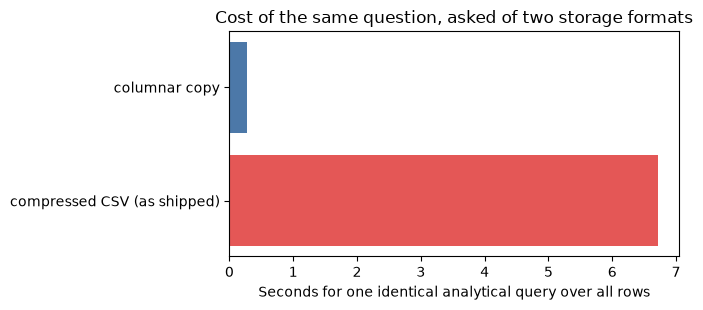


**What this shows.** The identical query takes **6.7s** against the compressed CSV
(297 MiB) and **0.3s** against the columnar copy
(177 MiB) — **25 times faster**. A compressed CSV must be decompressed and
re-parsed from the beginning on every query; a columnar format is parsed once and stores each column
separately.

**What this does not show.** These durations belong to this machine and this DuckDB configuration; a
different machine will give different absolute numbers, though the *ratio* between formats should
survive. The columnar copy is scratch — a throwaway artifact for this notebook, not a curated dataset.

**Why it matters next.** Every full-data diagnostic in sections 5–8 above ran against the columnar
copy, which is why they were affordable at full scale rather than needing a sample.


In [8]:
# Time one real workload against the file as shipped and against the columnar copy already in use.
workload = f'SELECT {TREATMENT}, ' + ', '.join(f'AVG({f}), VAR_SAMP({f})' for f in FEATURES) + f' FROM {{table}} GROUP BY {TREATMENT}'

start = time.perf_counter()
con.execute(workload.format(table='raw')).fetchall()
compressed_seconds = time.perf_counter() - start

start = time.perf_counter()
con.execute(workload.format(table='data')).fetchall()
columnar_seconds = time.perf_counter() - start

compressed_mib = INPUT_PATH.stat().st_size / 2 ** 20
columnar_mib = PARQUET_PATH.stat().st_size / 2 ** 20
speedup = compressed_seconds / columnar_seconds if columnar_seconds > 0 else float('inf')

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(['compressed CSV (as shipped)', 'columnar copy'], [compressed_seconds, columnar_seconds],
        color=['#E45756', '#4C78A8'])
ax.set_xlabel('Seconds for one identical analytical query over all rows')
ax.set_title('Cost of the same question, asked of two storage formats')
fig.tight_layout()
plt.show()

display(Markdown(f'''
**What this shows.** The identical query takes **{compressed_seconds:.1f}s** against the compressed CSV
({compressed_mib:,.0f} MiB) and **{columnar_seconds:.1f}s** against the columnar copy
({columnar_mib:,.0f} MiB) — **{speedup:.0f} times faster**. A compressed CSV must be decompressed and
re-parsed from the beginning on every query; a columnar format is parsed once and stores each column
separately.

**What this does not show.** These durations belong to this machine and this DuckDB configuration; a
different machine will give different absolute numbers, though the *ratio* between formats should
survive. The columnar copy is scratch — a throwaway artifact for this notebook, not a curated dataset.

**Why it matters next.** Every full-data diagnostic in sections 5–8 above ran against the columnar
copy, which is why they were affordable at full scale rather than needing a sample.
'''))

## 10. Train / validation / held-out design

The data will be split once into 70% training, 15% validation, and 15% held-out test, stratified jointly on treatment and outcome so every partition has a comparable mix of arms and outcomes.

- **Training** fits candidate models.
- **Validation** drives every development decision: early stopping, hyperparameters, method comparison, model selection. Reusing it repeatedly during development is expected.
- **Held-out test** is opened exactly once, after every development decision is frozen, to produce the one evaluation this project treats as final. Nothing about feature handling, thresholds, model choice, or hyperparameters may be adjusted using held-out information.

This separation exists so the final reported number is a genuine estimate of out-of-sample performance, not one the modeling process was indirectly optimized to produce.

*This section describes the design. Constructing and sealing the actual split is completed when its execution task is implemented — no split exists yet, and nothing above depends on one.*

## 11. Preprocessing decisions

*Completed when its execution task is implemented. No preprocessing has been applied to any figure in this notebook — every diagnostic above ran on the released values as-is.*

## 12. Key takeaways

- **Ranking by conversion probability and ranking by treatment effect are different problems**, and can disagree almost completely for the same person.
- **The experiment is large and complete.** All ~14 million released rows are fully populated on every field used here; nothing is sampled or dropped, and full-data diagnostics are affordable once the data is stored in a columnar format.
- **The treatment split is heavily lopsided and conversion is rare.** The smaller arm caps precision for anything estimated within it; the count of conversions, not the count of rows, is the binding constraint on how finely the data can be sliced.
- **All four combinations of treatment and conversion occur**, so the basic contrasts an uplift model needs are supported at the global level.
- **The treated and control groups look alike** across means, variances, and distribution shape — consistent with random assignment, though never proof of it.
- **A meaningful share of rows are indistinguishable on the twelve features**, and reduced numeric precision manufactures further collisions that are not in the data — a concrete reason to work at full precision and keep every row.
- **Individual treatment effects are not measurable here.** Only one of the two potential outcomes is ever observed per row, so everything downstream estimates conditional averages, and should be read that way.

The data and experimental design are now ready for uplift modeling. The next notebook compares response-based targeting with explicit treatment-effect estimators — the random reference, the response baseline, the T-Learner, the X-Learner, and Causal Forest — on a common validation cohort.